In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    def __init__(self, data, _children = (), _op = '', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.grad = 0.0
        self.label = label
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self + other
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other
        
    
    def tanh(self):
        x = self.data
        th = math.tanh(x)
        out = Value(th, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - (th)**2) * out.grad 
            
        out._backward = _backward
        return out


    def __truediv__(self, other):
        return self * other ** - 1

    
    def __rtruediv__(self, other):
        return self * other **-1
    
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
            
        out._backward = _backward
        return out

    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "int/float powers only!!"
        out = Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            self.grad += (other * (self.data**(other-1))) * out.grad
        out._backward = _backward
        return out


    def __sub__(self, other):
        return self + (-other)

    
    def __rsub__(self, other):
        return self + (-other)
    
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        
        build_topo(self)
        self.grad = 1
        for node in reversed(topo):
            node._backward()
                

In [3]:
from graphviz import Digraph


def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in getattr(v, '_prev', []):
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        data_val = getattr(n, 'data', None)
        grad_val = getattr(n, 'grad', 0.0)
        try:
            data_str = f"{float(data_val):.4f}"
        except Exception:
            data_str = str(data_val)

        # Use str() instead of undefined string(), and fix label formatting
        dot.node(name=uid,
                 label="{ %s | data: %s | grad %.4f}" % (n.label, data_str, grad_val),
                 shape="record")

        # If this Value is the result of an operation, draw the op node
        if getattr(n, '_op', ''):
            op_node = uid + n._op
            dot.node(name=op_node, label=n._op)
            dot.edge(op_node, uid)

    # Connect children to the op node that produced their parent
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + getattr(n2, '_op', ''))

    return dot

In [35]:
# x1 = Value(2.0, label='x1')
# x2 = Value(0.0, label='x2')
# w1 = Value(-3.0, label='w1')
# w2 = Value(1.0, label='w2')
# b = Value(6.8813735870195432, label='b')
# x1w1 = x1 * w1; x1w1.label='x1w1'
# x2w2 = x2 * w2; x2w2.label='x2w2'
# x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
# n = x1w1x2w2 + b; n.label='n'
# o = n.tanh(); o.label='o'

In [4]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label='x1w1'
x2w2 = x2 * w2; x2w2.label='x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label="x1w1 + x2w2"
n = x1w1x2w2 + b; n.label='n'

e = (2*n).exp()
o = (e - 1) / (e + 1)

o.label='o'

In [6]:
o.backward()

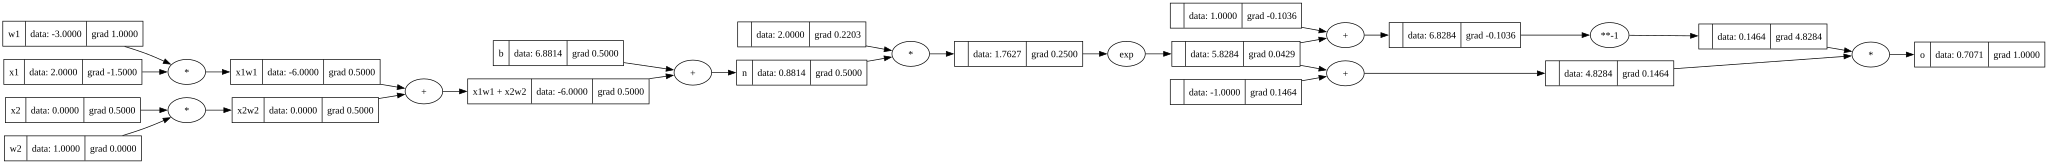

In [7]:
draw_dot(o)

In [8]:
# import torch

In [10]:
# x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
# x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
# w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
# w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
# b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

# n = x1 * w1 + x2 * w2 + b
# o = torch.tanh(n)
# print(o.data.item())
# o.backward()

# print('---')
# print('x2', x2.grad.item())
# print('w2', w2.grad.item())
# print('w1', w1.grad.item())
# print('x1', x1.grad.item())
# print('---')

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
w1 1.0000002567688737
x1 -1.5000003851533106
---


In [13]:
import random

In [50]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

In [55]:
x = [1.0, 2.0, -1.0]
n = MLP(3, [4, 4, 1])
o = n(x)

In [56]:
o.backward()

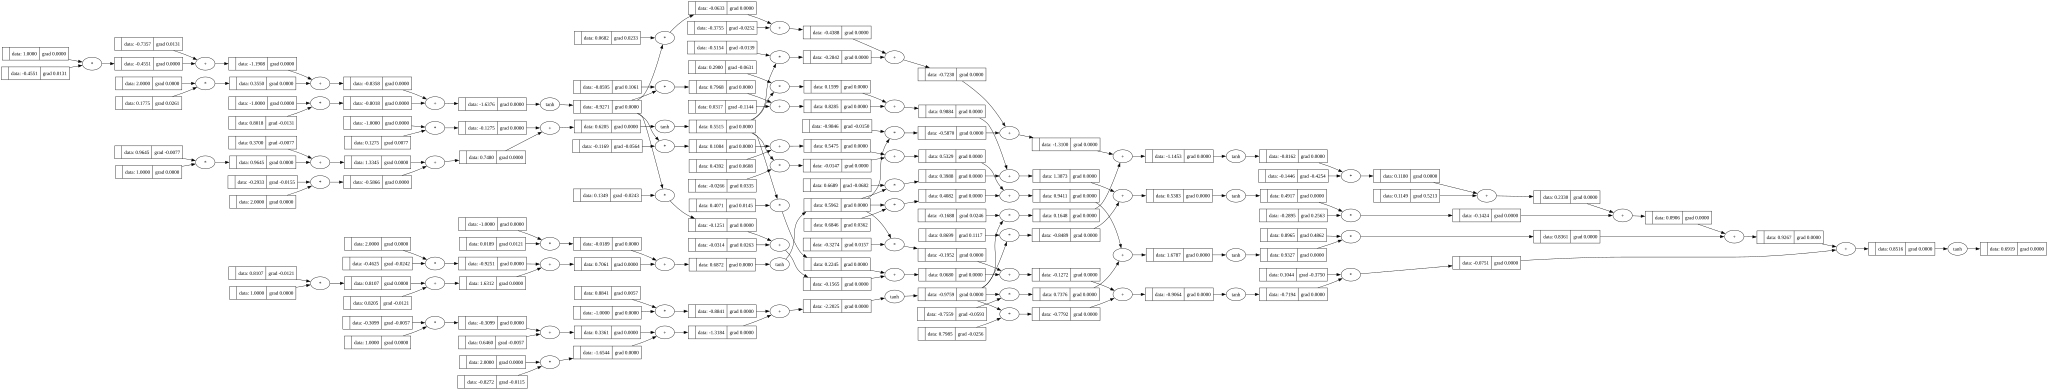

In [57]:
draw_dot(n(x))